## ⚠️ **Cette partie de code a été entierement générée par l'IA par curiosité de la complexité de la méthode du MSVAR. Cette méthode sera dans le cadre de notre étude non traitée étant donnée la limite de mots trop faible pour pouvoir dévellopper ce modèle de manière correcte**⚠️ 

<class 'pandas.DataFrame'>
Index: 105 entries, 12 to 174
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  105 non-null    float64
 1   gdp_nominal           105 non-null    float64
 2   expected_inflation    105 non-null    float64
 3   taux_changes          105 non-null    float64
 4   cpi                   105 non-null    float64
 5   taux_directeur        105 non-null    float64
 6   export                105 non-null    float64
 7   import                105 non-null    float64
 8   yield_perpetual       105 non-null    float64
 9   oil_price             105 non-null    float64
 10  gdp_cycle             105 non-null    float64
 11  gdp_trend             105 non-null    float64
 12  output_gap            105 non-null    float64
 13  taux_changes_stat     105 non-null    float64
 14  yield_perpetual_stat  105 non-null    float64
 15  gdp_nominal_stat      105 non-null    

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: 


================ MARKOV SWITCHING =================
                        Markov Switching Model Results                        
Dep. Variable:             output_gap   No. Observations:                   39
Model:               MarkovRegression   Log Likelihood                -260.348
Date:                Sun, 10 May 2026   AIC                            544.697
Time:                        12:20:01   BIC                            564.660
Sample:                             0   HQIC                           551.859
                                 - 39                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -15.8178     15.502     -1.020      0.308     -46.202      14.566

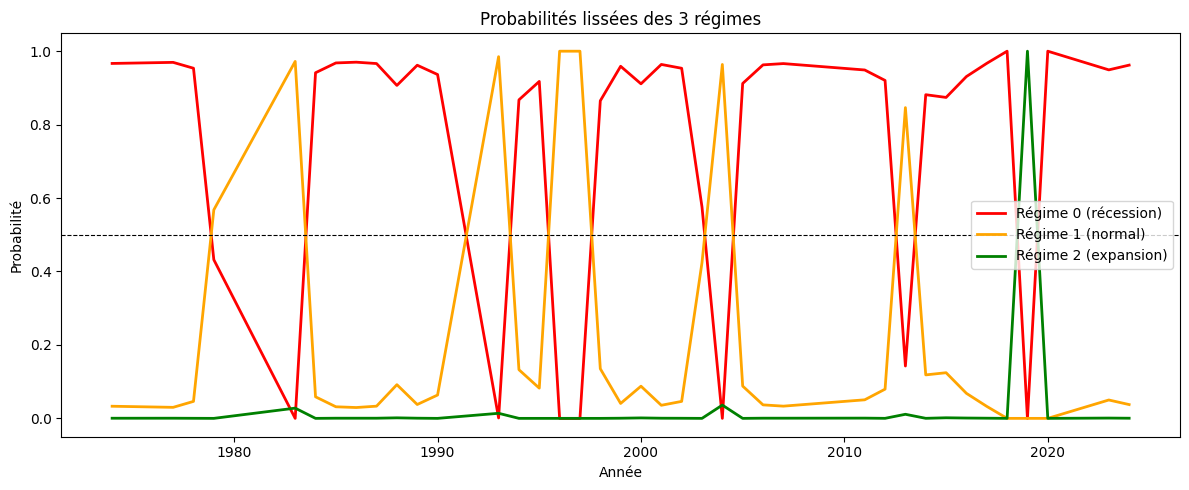

Observations régime 0 : 31
Observations régime 1 : 7
Observations régime 2 : 1

Estimation SVAR régime 0 (31 observations)...
================ SVAR REGIME 0 =================
  Summary of Regression Results   
Model:                        SVAR
Method:                        OLS
Date:           Sun, 10, May, 2026
Time:                     12:20:01
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   -1.05148
Nobs:                     29.0000    HQIC:                  -2.83248
Log likelihood:          -97.8990    FPE:                  0.0318987
AIC:                     -3.64462    Det(Omega_mle):      0.00638945
--------------------------------------------------------------------
Results for equation oil_price_stat
                          coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------------
const                   

/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/timeogrienti/economic_research/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


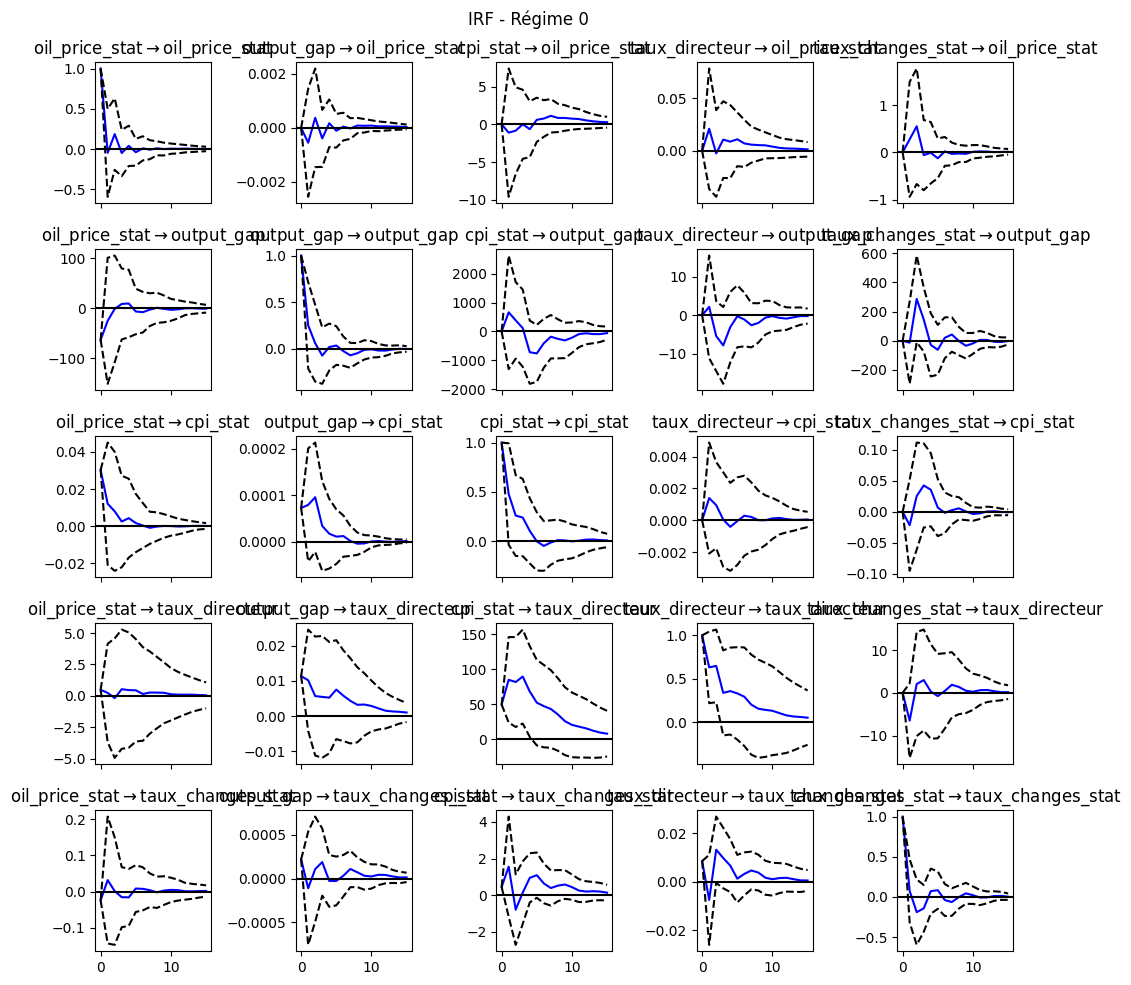


================ MATRICE DE TRANSITION =================
[[[7.72759897e-01]
  [6.60237247e-01]
  [1.00000000e+00]]

 [[1.89243249e-01]
  [3.39761804e-01]
  [6.61747183e-20]]

 [[3.79968546e-02]
  [9.48471984e-07]
  [0.00000000e+00]]]

================ STABILITÉ VAR =================
Roots VAR :
[-31.08541127-0.j           2.62393868-0.j
  -0.80629027+2.06471237j  -0.80629027-2.06471237j
   0.71562918+1.57886061j   0.71562918-1.57886061j
  -1.05604709+1.15396239j  -1.05604709-1.15396239j
   1.12011774+0.28807734j   1.12011774-0.28807734j]

Toutes les racines doivent être < 1 en module.

================ TERMINÉ =================
Résultats sauvegardés dans : ms_svar_results.csv


In [2]:
# ============================================================
# MS-SVAR SUR TES DONNÉES
# ============================================================

from DATALAKE.data import *

# Workaround for statsmodels 0.14.x bug: SVARResults missing k_exog_user
def svar_summary(res):
    if not hasattr(res, 'k_exog_user'):
        res.k_exog_user = 0
    return res.summary()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

from statsmodels.iolib.summary2 import summary_col

import sys
import os

sys.path.append("../dorian_code")

# ============================================================
# 1. CHARGEMENT DES DONNÉES
# ============================================================

path_parquet_file = '/Users/timeogrienti/economic_research/DATALAKE/PARQUET_FOLDER/main_detrended.parquet'

df_detrended = pd.read_parquet(path_parquet_file)

print(df_detrended.info())

# ============================================================
# 2. VARIABLES DU SVAR
# ============================================================

variables_svar = [
    'oil_price_stat',
    'output_gap',
    'cpi_stat',
    'taux_directeur',
    'taux_changes_stat'
]

# ============================================================
# 3. SOUS-PÉRIODES HISTORIQUES
# ============================================================

df_gold = (
    df_detrended[df_detrended['year'] < 1914]
    .set_index('year')[variables_svar]
    .dropna()
)

df_bw = (
    df_detrended[
        (df_detrended['year'] >= 1945) &
        (df_detrended['year'] <= 1973)
    ]
    .set_index('year')[variables_svar]
    .dropna()
)

df_float = (
    df_detrended[df_detrended['year'] > 1973]
    .set_index('year')[variables_svar]
    .dropna()
)

# ============================================================
# 4. CHOIX DE LA PÉRIODE
# ============================================================

# Tu peux changer ici :
df = df_float.copy()

print("\n================ DATA =================")
print(df.head())

# ============================================================
# 5. ESTIMATION VAR
# ============================================================

lag_order = 2

var_model = VAR(df)

var_results = var_model.fit(lag_order)

print("\n================ VAR =================")
print(var_results.summary())

# ============================================================
# 6. MATRICE STRUCTURELLE (CHOLESKY)
# ============================================================

# Hypothèse d'identification :
#
# oil_price → output → inflation → taux → change
#
# Variables plus "exogènes" en haut

A = np.array([
    [1,   0,   0,   0,   0],
    ['E', 1,   0,   0,   0],
    ['E', 'E', 1,   0,   0],
    ['E', 'E', 'E', 1,   0],
    ['E', 'E', 'E', 'E', 1]
], dtype=object)

# ============================================================
# 7. ESTIMATION SVAR
# ============================================================

svar_model = SVAR(
    df,
    svar_type='A',
    A=A
)

svar_results = svar_model.fit(maxlags=lag_order)

print("\n================ SVAR =================")
print(svar_summary(svar_results))

# ============================================================
# 8. MARKOV SWITCHING — 3 RÉGIMES
# ============================================================

# Régimes : récession / normal / expansion
# On utilise l'output gap comme variable de régime

N_REGIMES = 3

ms_model = MarkovRegression(
    endog=df['output_gap'],
    k_regimes=N_REGIMES,
    trend='c',
    switching_variance=True
)

ms_results = ms_model.fit()

print("\n================ MARKOV SWITCHING =================")
print(ms_results.summary())

# ============================================================
# 9. PROBABILITÉS DES RÉGIMES
# ============================================================

# smoothed_marginal_probabilities : shape (n_obs, k_regimes)
# On assigne chaque observation au régime de probabilité maximale

probs = ms_results.smoothed_marginal_probabilities  # (n_obs, 3)

df['regime'] = np.argmax(probs.values, axis=1)

print("\n================ RÉGIMES =================")
print(df['regime'].value_counts().sort_index())

# ============================================================
# 10. PLOT DES PROBABILITÉS PAR RÉGIME
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

labels = ['Régime 0 (récession)', 'Régime 1 (normal)', 'Régime 2 (expansion)']
colors = ['red', 'orange', 'green']

for i in range(N_REGIMES):
    ax.plot(
        df.index,
        probs.values[:, i],
        label=labels[i],
        color=colors[i],
        linewidth=2
    )

ax.axhline(0.5, linestyle='--', color='black', linewidth=0.8)
ax.set_title("Probabilités lissées des 3 régimes")
ax.set_xlabel("Année")
ax.set_ylabel("Probabilité")
ax.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 11. SÉPARATION PAR RÉGIME
# ============================================================

regimes = {}
for i in range(N_REGIMES):
    regimes[i] = df[df['regime'] == i][variables_svar]
    print(f"Observations régime {i} :", len(regimes[i]))

# ============================================================
# 12. SVAR PAR RÉGIME
# ============================================================

# Nombre minimum d'observations pour estimer un SVAR(lag_order)
# avec k variables : k*lag_order + 1 (au strict minimum)
min_obs = len(variables_svar) * lag_order + 1

svar_regimes = {}
for i in range(N_REGIMES):
    n = len(regimes[i])
    if n < min_obs:
        print(f"\nRégime {i} : seulement {n} observations (minimum requis : {min_obs}). SVAR ignoré.")
        svar_regimes[i] = None
    else:
        print(f"\nEstimation SVAR régime {i} ({n} observations)...")
        svar_regimes[i] = SVAR(
            regimes[i],
            svar_type='A',
            A=A
        ).fit(maxlags=lag_order)
        print(f"================ SVAR REGIME {i} =================")
        print(svar_summary(svar_regimes[i]))

# ============================================================
# 13. IMPULSE RESPONSE FUNCTIONS
# ============================================================

horizon_irf = 15

for i in range(N_REGIMES):
    if svar_regimes[i] is not None:
        irf = svar_regimes[i].irf(horizon_irf)
        fig_irf = irf.plot(orth=False)
        plt.suptitle(f"IRF - Régime {i}")
        plt.tight_layout()
        plt.show()

# ============================================================
# 14. MATRICE DE TRANSITION
# ============================================================

print("\n================ MATRICE DE TRANSITION =================")
print(ms_results.regime_transition)

# ============================================================
# 15. TESTS / STABILITÉ
# ============================================================

print("\n================ STABILITÉ VAR =================")
print("Roots VAR :")
print(var_results.roots)
print("\nToutes les racines doivent être < 1 en module.")

# ============================================================
# 16. SAUVEGARDE DES PROBAS
# ============================================================

for i in range(N_REGIMES):
    df[f'prob_regime{i}'] = probs.values[:, i]

df.to_csv("ms_svar_results.csv")

print("\n================ TERMINÉ =================")
print("Résultats sauvegardés dans : ms_svar_results.csv")
